In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from flonacomldft.utils.io_utils import load_pickle_file, load_csv_file
from flonacomldft.internal_coordinates import Coordinates_mapping

In [9]:
# BERENDSEN MD DATA - MLP Models

mlps = [load_pickle_file("models/is{:d}_mlp_dic_training.pkl".format(mode_label)) for mode_label in [0, 1]]

zmats_train = [torch.cat([load_csv_file("datasets/is{:d}_{:s}_train.csv".format(mode_label, kind)).T for kind in ['flow', 'md']], dim=1).T for mode_label in [0, 1]]
zmats_test = [torch.cat([load_csv_file("datasets/is{:d}_{:s}_test.csv".format(mode_label, kind)).T for kind in ['flow', 'md']], dim=1).T for mode_label in [0, 1]]

In [10]:
coord_mapping = Coordinates_mapping()

xs_train = []
xs_train_logdetjacs = []
us_train = []

for mode_label in [0, 1]:
    xs, logdetjacs, us = coord_mapping.get_real_centered_from_internal(zmats_train[mode_label][:, :12], logdetjacs=zmats_train[mode_label][:, 14], energies=zmats_train[mode_label][:, 12], isomer=mode_label)
    xs_train.append(xs)
    xs_train_logdetjacs.append(logdetjacs)
    us_train.append(us)

/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an ind

In [11]:
xs_test = []
xs_test_logdetjacs = []
us_test = []

for mode_label in [0, 1]:
    xs, logdetjacs, us = coord_mapping.get_real_centered_from_internal(zmats_test[mode_label][:, :12], logdetjacs=zmats_test[mode_label][:, 14], energies=zmats_test[mode_label][:, 12], isomer=mode_label)
    xs_test.append(xs)
    xs_test_logdetjacs.append(logdetjacs)
    us_test.append(us)

In [12]:
u_target_train = torch.stack(us_train).detach().numpy()
u_predict_train = [mlps[mode_label]['model'](xs_train[mode_label]).T.detach().numpy() for mode_label in [0, 1]]

u_target_test = torch.stack(us_test).detach().numpy()
u_predict_test = [mlps[mode_label]['model'](xs_test[mode_label]).T.detach().numpy() for mode_label in [0, 1]]

u_target = {'train': u_target_train, 'test': u_target_test}
u_predict = {'train': u_predict_train, 'test': u_predict_test}

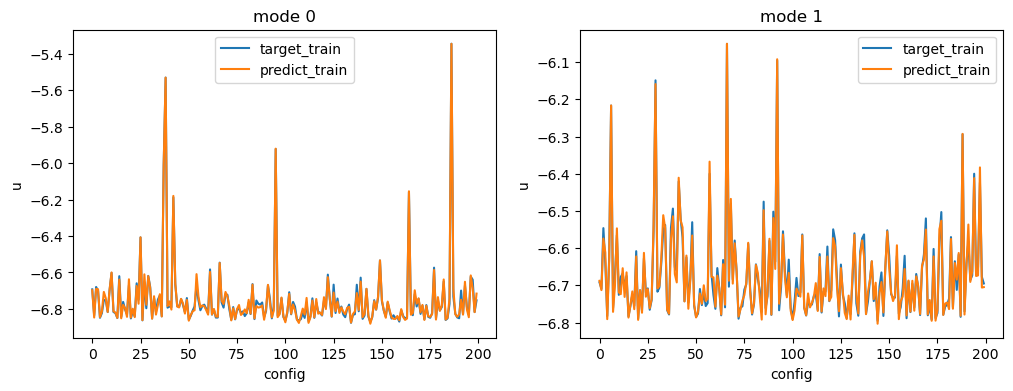

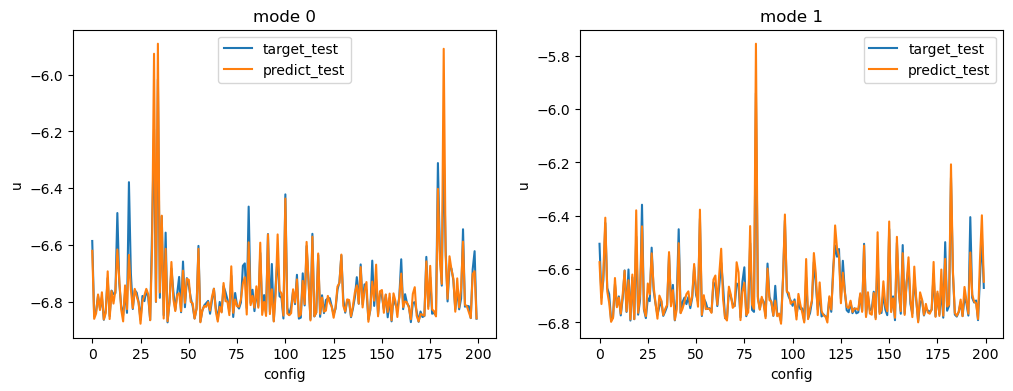

In [13]:
for datatype in ['train', 'test']:
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    for mode_label in [0, 1]:
        axs[mode_label].plot(u_target[datatype][mode_label].flatten()[:200], label = 'target_{:s}'.format(datatype))
        axs[mode_label].plot(u_predict[datatype][mode_label].flatten()[:200], label = 'predict_{:s}'.format(datatype))
        axs[mode_label].set_ylabel('u')
        axs[mode_label].set_xlabel('config')
        axs[mode_label].legend()
        axs[mode_label].set_title('mode {:d}'.format(mode_label))

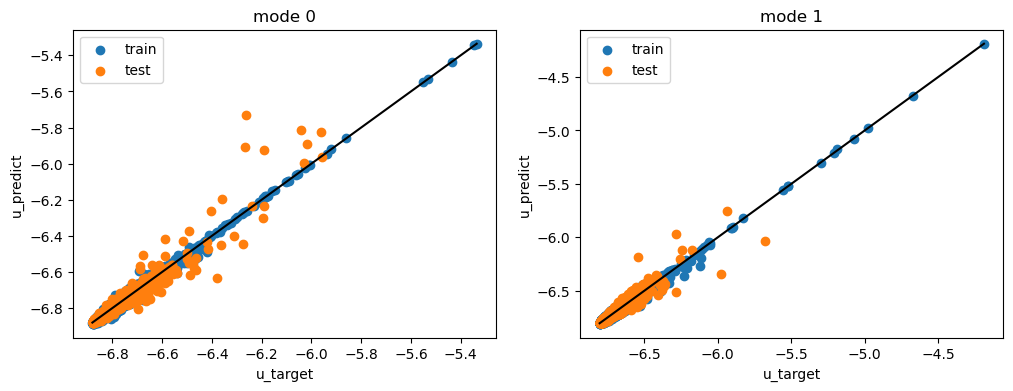

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for mode_label in [0, 1]:
    axs[mode_label].scatter(u_target['train'][mode_label].flatten(), u_predict['train'][mode_label].flatten(), label='train')
    axs[mode_label].scatter(u_target['test'][mode_label].flatten(), u_predict['test'][mode_label].flatten(), label='test')
    min_ = np.min(u_target['train'][mode_label].flatten())
    max_ = np.max(u_target['train'][mode_label].flatten())
    range_ = np.linspace(min_, max_, 2)
    axs[mode_label].plot(range_, range_, color='k')
    axs[mode_label].set_ylabel('u_predict')
    axs[mode_label].set_xlabel('u_target')
    axs[mode_label].legend()
    axs[mode_label].set_title('mode {:d}'.format(mode_label))